# Stormwater System Simulation

Here we implement a simulated stormwater system for the paper "Bootstrapping Actor-Critic and Deep-Q Agents with Imitation Learning for the Control of Semi-Empirical Storm-Water Systems". The system is explained in depth in the paper.

#### Imports

In [1]:
import random as r
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tqdm import tqdm

#### Notebook parameters

This is where we put anything we may wish to vary but which does not directly impact the simulation, such as whether to print test results.

In [2]:
testFunctions = False #Whether to run a bunch of diagnostic test code
shortTest = False #Whether to display the results of a short test for each agent
saveModels = False #Whether to save the models to .weights.h5
trainAgents = False #Train agents if true, load from .weights.h5 if false
seedRandomness = True
if seedRandomness:
    r.seed(1)
    
#reinforcement learning parameters
bootstrappingGenerations = 25 #How many quick generations to train on the plain reward without bellman
generationSize = 50 #How many predictions to train on in each generation
numGenerations = 25 #How many full training generations each model gets
finetuningGenerations = 10 #For the fine-tuned agents, how many generations to fine-tune for.
verbosity = False #Whether neural networks should display predictions

#### Simulation Parameters

Anything needed for the simulation which could in principle be changed goes here.

In [3]:
#Physical properties
drainConstantInlet = 0.75 #Affects how quickly water flows inlet->well
drainConstantStorage = 0.75 #Affects how quickly water flows storage->well

#Tank/Pump parameters
inletCapacity = 50 #Inlet volume in m3
wellCapacity = 500 #Well volume in m3
storageCapacity = 1800 #Storage volume in m3
pumpOutMax = 0.6 #If pump out is set to max, how much volume (m3) leaves per second?
pumpStorageMax = 1.5 #If pump out is set to max, how much volume (m3) passes to storage per second?

#### Physics

Any important constants or functions which could not in principle be chnaged go here.

In [4]:
def gravityDrain(volume, drainConstant):
    return(drainConstant * (volume) ** 0.5)

#Inflow data
inflowData = np.loadtxt("validationLow.txt", dtype = float).tolist()

#### System class

In [5]:
class System:
    def __init__(
        self, 
        volumes = [0, 0, 0],
        pumps = [1, 0],
        valve = 0,
        totalPumpUse = 0,
        volumeSpilled = 0,
        time = 0
    ):
        self.inletV = volumes[0]
        self.wellV = volumes[1]
        self.storageV = volumes[2]
        self.pumpStorage = pumps[0]
        self.pumpOut = pumps[1]
        self.valve = valve
        self.totalPumpUse = totalPumpUse
        self.volumeSpilled = volumeSpilled
        self.time = time

    #Used to create dummy systems
    def copySystem(self):
        return(System([self.inletV, self.wellV, self.storageV], [self.pumpStorage, self.pumpOut], self.valve, self.volumeSpilled, self.time))

    #Make any valid system state - used for training
    def generateRandomSystem(self):
        inletV = r.uniform(0, inletCapacity)
        wellV = r.uniform(0, wellCapacity)
        storageV = r.uniform(0, storageCapacity)
        pumpS = r.uniform(0, 1)
        pumpO = r.uniform(0, 1)
        valve = r.choice([0, 1])
        time = r.randint(0, len(inflowData))
        return(System([inletV, wellV, storageV], [pumpS, pumpO], valve, self.totalPumpUse, self.volumeSpilled, time))

    def generateTestSystem(self):
        inletV = r.uniform(inletCapacity/4, 3 * inletCapacity/4)
        wellV = r.uniform(wellCapacity/4, 3 * wellCapacity/4)
        storageV = r.uniform(storageCapacity/4, 3 * storageCapacity/4)
        pumpS = r.uniform(0, 1)
        pumpO = r.uniform(0, 1)
        valve = r.choice([0, 1])
        time = r.randint(0, len(inflowData))
        return(System([inletV, wellV, storageV], [pumpS, pumpO], valve, 0, 0, time))

    '''Data Management'''
    def getFullnesses(self):
        return(np.array([self.inletV / inletCapacity, self.wellV / wellCapacity, self.storageV / storageCapacity]))

    '''Simulation logic'''
    def getInflow(self):
        time = self.time
        return(inflowData[time % len(inflowData)])

    def updateSystemOneSecond(self, inputChoices):
        choices = [0 if c < 0 else 1 if c > 1 else c for c in inputChoices]
        
        #Update pump state if needed
        self.pumpStorage = choices[0]
        self.pumpOut = choices[1]
        self.valve = 0 if choices[2] < 0.5 else 1

        self.totalPumpUse +=  (self.pumpStorage * pumpStorageMax) + (self.pumpOut * pumpOutMax)

        #Update well->exit first, then well and storage together, then inlet and well together
        self.wellV -=  min(self.pumpOut * pumpOutMax, self.wellV)

        #Well -> storage
        wellToStorageV = min(self.pumpStorage * pumpStorageMax, self.wellV)
        storageToWellV = min(gravityDrain(self.storageV, drainConstantStorage), self.storageV) * self.valve
        netWellToStorageV = wellToStorageV - storageToWellV
        if netWellToStorageV > 0:
            #passing to storage
            volumePassedWS = min(netWellToStorageV, storageCapacity - self.storageV)
            self.storageV +=  volumePassedWS
            self.wellV -=  volumePassedWS
        else:
            #passing to well
            volumePassedSW = min(-netWellToStorageV, wellCapacity - self.wellV)
            self.storageV -=  volumePassedSW
            self.wellV +=  volumePassedSW

        #Inlet->Well
        inletToWellV = min(gravityDrain(self.inletV, drainConstantInlet), self.inletV)
        volumePassedIW = min(inletToWellV, wellCapacity - self.wellV)
        self.inletV -=  volumePassedIW
        self.wellV +=  volumePassedIW
        
        #Any spillage
        inflowV = self.getInflow()
        if inletCapacity - self.inletV > inflowV:
            self.inletV +=  inflowV
        else:
            #Inlet is full!
            self.volumeSpilled +=  inflowV - (inletCapacity - self.inletV)
            self.inletV = inletCapacity
        self.time +=  1
        return(self)
    
    def updateSystem(self, pumps, timesteps = 15 * 60):
        for i in range(timesteps):
            self.updateSystemOneSecond(pumps)
        return(self)
    
    '''Interpretability stuff'''
    def displaySystem(self):
        print(f"Inlet volume: {self.inletV}")
        print(f"Well volume: {self.wellV}")
        print(f"Storage volume: {self.storageV}")
        print(f"Storage pump: {self.pumpStorage}")
        print(f"Exit pump: {self.pumpOut}")
        print(f"Valve: {self.valve}")
        print(f"Volume Spilled: {self.volumeSpilled}")
        print(f"Time: {self.time}")

if testFunctions:
    dummySystem = System()
    print(dummySystem.getFullnesses())
    print(dummySystem.getInflow())
    dummySystem.displaySystem()

#### Agent Handler

Agent Handler assumes we have an agent we have chosen to deploy. We can do tests of the agent, record and/or dissplay data, and any other data management. Agent Handler treats "agent" as a black box with a "predict" function which maps states onto actions.

In [6]:
#How to label data
inputLabels = ["Inlet Chamber", "Well", "Storage"]
outputLabels = ["Storage Pump", "Exit Pump", "Storage valve"]
dataLabels = ["Mean overflow rate (m3/decision number)", "Mean Pump Use (m3/s)"]
xLabel = "Decision number"
inputY = "Water level (m)"
outputY = "State"
dataY = ["Mean overflow rate (m3/s)", "Mean pump use (m3/s)"]
inputTitle = "Water level (m) versus decision number"
outputTitle = "Pumping and valve state versus decision number"
dataTitle = ["Mean overflow rate (m3/s) versus decision number", "Mean pump use (m3/s) versus decision number"]
plotRanges = True #prefer ranges or quartiles
saveFigs = True #whether to save graphs as a .png
saveData = True #Whether to save data as .txt

class AgentHandler:
    def __init__(self, agent):
        self.agent = agent

    #Test the agent once, and return the data
    def singleTest(self, testLength = 100):
        system = System().generateTestSystem()
        fullData = []
        outputData = []
        measureData = []

        for i in tqdm(range(testLength)):
            agentInput = system.getFullnesses()
            fullData.append(agentInput)

            agentDecision = self.agent.predict(agentInput)
            agentDecision = [0 if c < 0 else 1 if c > 1 else c for c in agentDecision]
            agentDecision[2] = 0 if agentDecision[2] < 0.5 else 1
            outputData.append(agentDecision)

            meanSpill = system.volumeSpilled / (15 * 60 * (i + 1))
            meanPump = system.totalPumpUse / (15 * 60 * (i + 1))

            measureData.append(np.array([meanSpill, meanPump]))

            system.updateSystem(agentDecision)

        fullData = np.array(fullData)
        outputData = np.array(outputData)
        measureData = np.array(measureData)
        return [fullData, outputData, measureData]

    def displayData(self, data, showInputs = True, showOutputs = True, showMeasures = True):
        if showInputs:
            plt.plot(data[0])
            plt.show()
        if showOutputs:
            plt.plot(data[1])
            plt.show()
        if showMeasures:
            plt.plot(data[2])
            plt.show()

    def processData(self, data):
        outputs = []
        for row in data:
            subRow = []
            transRow = np.array(row).T
            for element in transRow:
                subRow.append(np.percentile(transRow, 0))
                subRow.append(np.percentile(transRow, 25))
                subRow.append(np.median(transRow))
                subRow.append(np.percentile(transRow, 75))
                subRow.append(np.percentile(transRow, 100))
            outputs.append(transRow)
        outputs = np.array(outputs)
        return(outputs.T)

    def fullTest(self, nRepeats  =  10, fullTestLength = 24 * 4, savename = ""):
        print(f"testing {savename}...")
        inputsMatrix = []
        outputsMatrix = []
        dataMatrix = []
        for i in range(nRepeats):
            row = self.singleTest(fullTestLength)
            inputsMatrix.append(self.processData(row[0]))
            outputsMatrix.append(self.processData(row[1]))
            dataMatrix.append(self.processData(row[2]))
        inputsMatrix = np.array(inputsMatrix)   
        outputsMatrix = np.array(outputsMatrix)
        dataMatrix = np.array(dataMatrix)
        for i in range(inputsMatrix.shape[1]):
            p0 = np.percentile(inputsMatrix[:, i, :], 0, axis = 0)
            p25 = np.percentile(inputsMatrix[:, i, :], 25, axis = 0)
            p50 = np.percentile(inputsMatrix[:, i, :], 50, axis = 0)
            p75 = np.percentile(inputsMatrix[:, i, :], 75, axis = 0)
            p100 = np.percentile(inputsMatrix[:, i, :], 100, axis = 0)
            plt.plot(range(len(p50)), p50, label = inputLabels[i])
            plt.xlim(0, len(p50))
            plt.xlabel(xLabel)
            plt.ylabel(inputY)
            plt.title(inputTitle)
            plt.grid(True)
            plt.legend()
            if plotRanges:
                plt.fill_between(range(len(p50)), p0, p100, alpha = 0.3)
                plt.legend(loc = "upper right", fontsize = 12)
            else:
                plt.fill_between(range(len(p50)), p25, p75, alpha = 0.3)
                plt.legend(loc = "upper right", fontsize = 12)
            if saveFigs:
                plt.savefig("inputs" + savename + f"_{i}.png")
        plt.show()
        for i in range(outputsMatrix.shape[1]):
            p0 = np.percentile(outputsMatrix[:, i, :], 0, axis = 0)
            p25 = np.percentile(outputsMatrix[:, i, :], 25, axis = 0)
            p50 = np.percentile(outputsMatrix[:, i, :], 50, axis = 0)
            p75 = np.percentile(outputsMatrix[:, i, :], 75, axis = 0)
            p100 = np.percentile(outputsMatrix[:, i, :], 100, axis = 0)
            plt.plot(range(len(p50)), p50, label = outputLabels[i])
            plt.xlim(0, len(p50))
            plt.xlabel(xLabel)
            plt.ylabel(outputY)
            plt.title(outputTitle)
            plt.grid(True)
            plt.legend()
            if plotRanges:
                plt.fill_between(range(len(p50)), p0, p100, alpha = 0.3)
                plt.legend(loc = "upper right", fontsize = 12)
            else:
                plt.fill_between(range(len(p50)), p25, p75, alpha = 0.3)
                plt.legend(loc = "upper right", fontsize = 12)
            if saveFigs:
                plt.savefig("outputs" + savename + f"_{i}.png")
        plt.show()
        for i in range(dataMatrix.shape[1]):
            p0 = np.percentile(dataMatrix[:, i, :], 0, axis = 0)
            p25 = np.percentile(dataMatrix[:, i, :], 25, axis = 0)
            p50 = np.percentile(dataMatrix[:, i, :], 50, axis = 0)
            p75 = np.percentile(dataMatrix[:, i, :], 75, axis = 0)
            p100 = np.percentile(dataMatrix[:, i, :], 100, axis = 0)
            plt.plot(range(len(p50)), p50, label = dataLabels[i])
            plt.xlim(0, len(p50))
            plt.xlabel(xLabel)
            plt.ylabel(dataY[i])
            plt.title(dataTitle[i])
            plt.grid(True)
            plt.legend()
            if plotRanges:
                plt.fill_between(range(len(p50)), p0, p100, alpha = 0.3)
                plt.legend(loc = "upper right", fontsize = 12)
            else:
                plt.fill_between(range(len(p50)), p25, p75, alpha = 0.3)
                plt.legend(loc = "upper right", fontsize = 12)
            if saveFigs:
                plt.savefig("data" + savename + f"_{i}.png")
            plt.show()
        if saveData:
            np.save("inputsMatrix" + savename + ".npy", inputsMatrix)
            np.save("outputsMatrix" + savename + ".npy", outputsMatrix)
            np.save("dataMatrix" + savename + ".npy", dataMatrix)
        print(f"{savename} complete!")
        print("")
        print("")
        print("")

#### Random Agent

The random agent class is mostly used to test the agent handler and as a control. If your agent isn't doing better than literally picking actions at random, it's back to the drawing board!

In [7]:
class RandomAgent:
    def __init__(self):
        pass
    def predict(self, fullnesses):
        output = np.array([r.uniform(0, 1) for i in range(3)])
        if output[2] > 0.5:
            output[2] = 1
        else:
            output[2] = 0
        return(output)
random = RandomAgent()

#### Optimizers

Any optimization algorithms that are not inherently part of the RL classes themselves go here.

In [8]:
#Modified random search class which expects "fullnesses" as an argument.
class RandomSearch:
    def __init__(
        self,
        ranges
    ):
        self.ranges = ranges
        
    def generateRandomHypothesis(self):
        output = []
        for x in self.ranges:
            output.append(r.uniform(x[0], x[1]))
        return(output)
    
    def optimize(self, objectiveFunction, fullnesses, numIterations = 25):
        bestX = None
        bestY = -float("inf")
        for i in range(numIterations):
            newX = self.generateRandomHypothesis()
            newY = objectiveFunction(newX, fullnesses)
            if newY > bestY:
                bestX = newX
                bestY = newY
        return(bestX)
        
ranges = [[0, 1] for c in range(3)]
randomsearch = RandomSearch(ranges)

class SimulatedAnnealing:
    def __init__(
        self,
        ranges
    ):
        self.ranges = ranges
    
    def optimize(self, objectiveFunction, initialX, fullnesses, numIterations = 25, standardDeviation = 0.05, coolingFactor = 0.8):
        currentX = initialX
        currentY = objectiveFunction(currentX, fullnesses)
        heat = 1
        for i in range(numIterations):
            heat = heat * coolingFactor
            newX = [r.gauss(x, standardDeviation) for x in currentX]
            newY = objectiveFunction(newX, fullnesses)
            if newY > currentY:
                currentY = newY
                currentX = newX
            else:
                prob = r.uniform(0, 1)
                if prob > np.e ** -(currentY - newY)/(heat + (10 ** -10)):
                    currentY = newY
                    currentX = newX
        
        return(currentX)
simulatedannealing = SimulatedAnnealing(ranges)

#### PLC 

We use a threshold PLC. If the water level in the well is above outThreshold we put pumpOut fully on, and if it's below the threshold we put pumpOut fully off. If the waterLevel is above storageThresholdLow and above storageThresholdHigh, the pumping to storage is linear within this range. Otherwise, it is fully off (below) or fully on (above). The valve is open if we are below storageThresholdLow.

In [9]:
outThreshold = 0.2
storageThresholdLow = 0.25
storageThresholdHigh = 0.5

class PLC:
    def __init__(self, out, low, high):
        self.out = out
        self.low = low
        self.high = high
    def predict(self, fullnesses):
        low = self.low
        high = self.high
        out = self.out
        wellV = fullnesses[1]
        output = []
        if wellV < low:
            output.append(0)
        elif wellV > high:
            output.append(1)
        else:
            output.append(((wellV - low)/ (high - low)) ** 2)
        output.append(0 if wellV < out else 1)
        output.append(1 if wellV < low else 0)
        output = np.array(output)
        return(output)

plc = PLC(outThreshold, storageThresholdLow, storageThresholdHigh)

#### Reinforcement Learning Tools

Anything needed to run reinforcement learning algorithms which doesn't belong in a single class goes here.

In [10]:
def pickRandomAction():
    output = [r.uniform(0, 1) for c in range(3)]
    if output[2] < 0.5:
        output[2] = 0
    else:
        output[2] = 1
    return(output)

#Rewards for system states only, ignoring actions
def utilityFunction(system):
    fullnesses = system.getFullnesses()
    wellPunish = (fullnesses[1] - 0.2) ** 2 / (0.8 ** 2)
    storagePunish = (fullnesses[2] - 0.2) ** 2 / (0.8 ** 2)
    return(1 - (wellPunish + storagePunish)/2)

#This is the actual reward the RL agents must optimize. 
def reward(system, action):
    
    system1 = system.copySystem()
    utility1 = utilityFunction(system1)
    system2 = system.copySystem()
    system2.updateSystem(action)
    utility2 = utilityFunction(system2)

    output = utility2 - utility1
    
    output = 0.95 * output #So bellman doesn't make rewards >1
    
    assert(np.fabs(output) <=  0.95) #Reward must be -1 <=  reward <=  1
    return(output)

#For each agent, look ahead one timestep and reward not just immediate behaviour but also future consequences
def bellman(system, action, agent, discountFactor = 0.05, lookahead = 1):
    dummySystem = system.copySystem()
    output = reward(dummySystem, action)
    dummySystem = dummySystem.updateSystem(action)
    for i in range(lookahead):
        agentInputs = dummySystem.getFullnesses()
        nextAction = agent.predict(agentInputs)
        output +=  (discountFactor ** (i + 1)) * reward(dummySystem, nextAction)
        dummySystem = dummySystem.updateSystem(action)
    assert(np.fabs(output) <=  1) #Reward must be -1 <  =  reward <  =  1
    return(output)

#0 if the actions are the same, 1 if they are maximally distant
def imitationDistance(system, action):
    agentInputs = system.getFullnesses()
    plcAction = plc.predict(agentInputs)
    output = 0
    for i in range(len(plcAction)):
        output +=  (plcAction[i] - action[i]) ** 2
    output = output / 3
    return(output)

#1 if the actions are the same, -1 if they are maximally distant
def imitationDistanceReward(system, action):
    output = 1 - (2 * imitationDistance(system, action))
    return(output)
    
if testFunctions: 
    system.displaySystem()
    print(reward(system, [0, 0, 0]))
    print(bellman(system, [0, 0, 0], random))
    system.displaySystem()

#### Greedy Agent

In general just greedily argmaxing on the reward function will perform poorly since it doesn't consider long-term consequences of actions, but it works as a check that the reward function is sensible: if this behaviour is extremely poor then chances are the reward is sub-optimal.

In [11]:
class Greedy:
    def __init__(self, rewardFunction, optimizer):
        self.rewardFunction = rewardFunction
        self.optimizer = optimizer
    def predict(self, fullnesses):
        def objective(action, fullnesses):
            dummySystem = System(fullnesses)
            dummySystem.inletV = fullnesses[0] * inletCapacity
            dummySystem.wellV = fullnesses[1] * wellCapacity
            dummySystem.storageV = fullnesses[2] * storageCapacity
            return(self.rewardFunction(dummySystem, action))
        return(self.optimizer.optimize(objective, fullnesses))
greedy = Greedy(reward, randomsearch)
greedyI = Greedy(imitationDistanceReward, randomsearch)

#### Model Architectures

In [12]:
def valueModel():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape = (6,)),
        tf.keras.layers.Dense(6, activation = "tanh"),
        tf.keras.layers.Dense(12, activation = "tanh"),
        tf.keras.layers.Dense(24, activation = "tanh"),
        tf.keras.layers.Dense(12, activation = "tanh"),
        tf.keras.layers.Dense(6, activation = "tanh"),
        tf.keras.layers.Dense(1, activation = "tanh")
    ])
    model.compile(loss = "mse", optimizer = "adam")
    return(model)

#Custom loss function for policy
def customLoss(eps = 0.1, k = 20.0):
    def loss(y_true, y_pred):
        e = tf.abs(y_true - y_pred)
        ramp = tf.math.softplus(k*(e - eps)) / k
        return tf.reduce_mean(tf.square(ramp))
    return loss


def policyModel():
    inputs = tf.keras.layers.Input(shape=(3,))
    x = tf.keras.layers.Dense(6,  activation = "tanh")(inputs)
    x = tf.keras.layers.Dense(12, activation = "tanh")(x)
    x = tf.keras.layers.Dense(24, activation = "tanh")(x)
    x = tf.keras.layers.Dense(12, activation = "tanh")(x)
    x = tf.keras.layers.Dense(6,  activation = "tanh")(x)
    z = tf.keras.layers.Dense(3, activation = None, bias_initializer = tf.keras.initializers.RandomUniform(-1.5, 1.5))(x)
    out = tf.keras.layers.Lambda(lambda t: 0.5*(tf.tanh(t) + 1.0))(z)
    model = tf.keras.Model(inputs, out)
    model.compile(optimizer="adam", loss = customLoss(0.1))
    return(model)

#### DeepQ

Our deepQ agent maps pairs of states and actions onto values, and then we pick the highest value action using an optimization algorithm.

In [13]:
system = System()
qModel = valueModel()

class DeepQ:
    def __init__(self, model, optimizer):
        self.model = model
        self.optimizer = optimizer
        
    #Get a Q-value from a state-action pair. Does not give an action as output.
    def evaluate(self, fullnesses, action):
        modelInp = []
        for f in fullnesses:
            modelInp.append(f)
        for a in action:
            modelInp.append(a)
        modelInp = np.array([modelInp])
        output = self.model.predict(modelInp, verbose = verbosity)
        return(output)

    #Evaluates the value of action from the current state. 
    def evaluateGlobal(self, action, fullnesses):
        return(self.evaluate(fullnesses, action))
    
    #Predict an action using the optimizer and evaluate()
    def predict(self, fullnesses):
        initialX = greedy.predict(fullnesses) 
        output = self.optimizer.optimize(self.evaluateGlobal, initialX, fullnesses)
        #output = [int(x > 0.5) for x in output]
        return(output)

    #Get training data - one training generation
    def getInitialTrainingData(self, trainingLength = generationSize):
        xlabels = []
        ylabels = []
        for i in tqdm(range(trainingLength)):
            system = System().generateRandomSystem()
            xlabel = []
            fullnesses = system.getFullnesses()
            action = pickRandomAction()
            for f in fullnesses:
                xlabel.append(f)
            for a in action:
                xlabel.append(a)
            xlabels.append(xlabel)
            ylabels.append(reward(system, action))
        xlabels = np.array(xlabels)
        ylabels = np.array(ylabels)
        return([xlabels, ylabels])
    
    #Get training data - one training generation
    def getTrainingData(self, trainingLength = generationSize):
        xlabels = []
        ylabels = []
        for i in tqdm(range(trainingLength)):
            system = System().generateRandomSystem()
            xlabel = []
            fullnesses = system.getFullnesses()
            action = pickRandomAction()
            for f in fullnesses:
                xlabel.append(f)
            for a in action:
                xlabel.append(a)
            xlabels.append(xlabel)
            ylabels.append(bellman(system, action, self))
        xlabels = np.array(xlabels)
        ylabels = np.array(ylabels)
        return([xlabels, ylabels])

    #Train one generation with initial data
    def trainOnceInitial(self):
        trainingData = self.getInitialTrainingData()
        self.model.fit(trainingData[0], trainingData[1], verbose = verbosity)

    #Train one generation
    def trainOnce(self):
        trainingData = self.getTrainingData()
        self.model.fit(trainingData[0], trainingData[1], verbose = verbosity)

    #Train all the generations
    def fullTrain(self):
        for i in range(bootstrappingGenerations):
            self.trainOnceInitial()
        for i in range(numGenerations):
            self.trainOnce()
        
deepq = DeepQ(qModel, simulatedannealing)
if trainAgents:
    deepq.fullTrain()
else:
    deepq.model.load_weights("deepq_model.weights.h5")
if testFunctions:
    print(deepq.evaluate([1, 1, 1], [1, 1, 1]))
    print(deepq.predict([1, 1, 1]))

if shortTest:
    handler = AgentHandler(deepq)
    testData = handler.singleTest()
    handler.displayData(testData)

if saveModels:
    deepq.model.save_weights("deepq_model.weights.h5")

C:\Users\Daisy W\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:418: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  trackable.load_own_variables(weights_store.get(inner_path))


#### Actor-Critic

Here we train a policy-based actor to map states to actions directly. The critic acts like a deepQ model, mapping state-action pairs to values, and the actor must learn a policy which pleases the critic.

In [14]:
system = System() #Must have a system to act on or .predict() will throw an error
actorModel = policyModel()
criticModel = valueModel()

class ActorCritic:
    def __init__(self, actor, critic, optimizer):
        self.actor = actor
        self.critic = critic
        self.optimizer = optimizer
        
    #Get a critic prediction from a state-action pair. Does not give an action as output.
    def evaluate(self, fullnesses, action):
        modelInp = []
        for f in fullnesses:
            modelInp.append(f)
        for a in action:
            modelInp.append(a)
        modelInp = np.array([modelInp])
        output = self.critic.predict(modelInp, verbose = verbosity)
        return(output)

    #Evaluates the value of action from the current state. 
    def evaluateGlobal(self, action, fullnesses):
        return(self.evaluate(fullnesses, action))
    
    #Use the critic and the optimizer to pick an action
    def predictWithCritic(self, fullnesses):
        initialX = greedy.predict(fullnesses) 
        output = self.optimizer.optimize(self.evaluateGlobal, initialX, fullnesses)
        return(output)

    #Use the actor to pick an action
    def predict(self, fullnesses):
        fullnesses = np.array(fullnesses).reshape(1, -1)
        output = self.actor.predict(fullnesses, verbose = verbosity)[0]
        #output = [int(x > 0.5) for x in output]
        return(output)

    #Get initial training data - one generation
    def getInitialTrainingData(self, generationSize):

        actorX = []
        actorY = []
        criticX = []
        criticY = []
        for i in tqdm(range(trainingLength)):
            system = System().generateRandomSystem()
            critX = []
            fullnesses = system.getFullnesses()
            actorX.append(fullnesses)
            actorY.append(greedy.predict(fullnesses))
            action = pickRandomAction()
            for f in fullnesses:
                critX.append(f)
            for a in action:
                critX.append(a)
            criticX.append(critX)
            criticY.append(reward(system, action))
        actorX = np.array(actorX)
        actorY = np.array(actorY)
        criticX = np.array(criticX)
        criticY = np.array(criticY)
        return([actorX, actorY, criticX, criticY])

    #Get training data - one training generation
    def getTrainingData(self, trainingLength = generationSize):

        actorX = []
        actorY = []
        criticX = []
        criticY = []
        for i in tqdm(range(trainingLength)):
            system = System().generateRandomSystem()
            critX = []
            fullnesses = system.getFullnesses()
            actorX.append(fullnesses)
            actorY.append(self.predictWithCritic(fullnesses))
            action = pickRandomAction()
            for f in fullnesses:
                critX.append(f)
            for a in action:
                critX.append(a)
            criticX.append(critX)
            criticY.append(bellman(system, action, self))
        actorX = np.array(actorX)
        actorY = np.array(actorY)
        criticX = np.array(criticX)
        criticY = np.array(criticY)
        return([actorX, actorY, criticX, criticY])

    #Train one generation
    def trainOnce(self):
        trainingData = self.getTrainingData()
        self.actor.fit(trainingData[0], trainingData[1], verbose = verbosity)
        self.critic.fit(trainingData[2], trainingData[3], verbose = verbosity)

    #Train one generation
    def trainOnceInitial(self):
        trainingData = self.getTrainingData()
        self.actor.fit(trainingData[0], trainingData[1], verbose = verbosity)
        self.critic.fit(trainingData[2], trainingData[3], verbose = verbosity)

    #Train all the generations
    def fullTrain(self):
        for i in range(bootstrappingGenerations):
            self.trainOnceInitial()
        for i in range(numGenerations):
            self.trainOnce()

actorcritic = ActorCritic(actorModel, criticModel, simulatedannealing)
if trainAgents:
    actorcritic.fullTrain()
else:
    actorcritic.actor.load_weights("actor_model.weights.h5")
    actorcritic.critic.load_weights("critic_model.weights.h5")
if shortTest:
    handler = AgentHandler(actorcritic)
    testData = handler.singleTest()
    handler.displayData(testData)

if saveModels:
    actorcritic.actor.save_weights("actor_model.weights.h5")
    actorcritic.critic.save_weights("critic_model.weights.h5")

#### Imitation Q

A value-based method where we learn distance from the plc action instead of a reward.

In [15]:
system = System() #Must have a system to act on or .predict() will throw an error
qModel = valueModel()

class ImitQ:
    def __init__(self, model, optimizer):
        self.model = model
        self.optimizer = optimizer
        
    #Get a Q-value from a state-action pair. Does not give an action as output.
    def evaluate(self, fullnesses, action):
        modelInp = []
        for f in fullnesses:
            modelInp.append(f)
        for a in action:
            modelInp.append(a)
        modelInp = np.array([modelInp])
        output = self.model.predict(modelInp, verbose = verbosity)
        return(output)

    #Evaluates the value of action from the current state. 
    def evaluateGlobal(self, action, fullnesses):
        return(self.evaluate(fullnesses, action))
    
    #Predict an action using the optimizer and evaluate()
    def predict(self, fullnesses):
        initialX = greedyI.predict(fullnesses) 
        output = self.optimizer.optimize(self.evaluateGlobal, initialX, fullnesses)
        #output = [int(x > 0.5) for x in output]
        return(output)

    #Get training data - one training generation
    def getTrainingData(self, trainingLength = generationSize):
        xlabels = []
        ylabels = []
        for i in tqdm(range(trainingLength)):
            system = System().generateRandomSystem()
            xlabel = []
            fullnesses = system.getFullnesses()
            action = pickRandomAction()
            for f in fullnesses:
                xlabel.append(f)
            for a in action:
                xlabel.append(a)
            xlabels.append(xlabel)
            ylabels.append(imitationDistanceReward(system, action))
        xlabels = np.array(xlabels)
        ylabels = np.array(ylabels)
        return([xlabels, ylabels])

    #Train one generation
    def trainOnce(self):
        trainingData = self.getTrainingData()
        self.model.fit(trainingData[0], trainingData[1], verbose = verbosity)

    #Train all the generations
    def fullTrain(self):
        for i in range(numGenerations):
            self.trainOnce()
        
imitationq = ImitQ(qModel, simulatedannealing)
if trainAgents:
    imitationq.fullTrain()
else:
    imitationq.model.load_weights("imitation_model.weights.h5")
    
if shortTest:
    handler = AgentHandler(imitationq)
    testData = handler.singleTest()
    handler.displayData(testData)

if saveModels:
    imitationq.model.save_weights("imitation_model.weights.h5")

#### Imitation actor-critic

Same deal, but with actor-critic architecture.

In [16]:
system = System() #Must have a system to act on or .predict() will throw an error
actorModel = policyModel()
criticModel = valueModel()

class ImitationActorCritic:
    def __init__(self, actor, critic, optimizer):
        self.actor = actor
        self.critic = critic
        self.optimizer = optimizer
        
    #Get a critic prediction from a state-action pair. Does not give an action as output.
    def evaluate(self, fullnesses, action):
        modelInp = []
        for f in fullnesses:
            modelInp.append(f)
        for a in action:
            modelInp.append(a)
        modelInp = np.array([modelInp])
        output = self.critic.predict(modelInp, verbose = verbosity)
        return(output)

    #Evaluates the value of action from the current state. 
    def evaluateGlobal(self, action, fullnesses):
        return(self.evaluate(fullnesses, action))
    
    #Use the critic and the optimizer to pick an action
    def predictWithCritic(self, fullnesses):
        initialX = greedyI.predict(fullnesses)
        output = self.optimizer.optimize(self.evaluateGlobal, initialX, fullnesses)
        return(output)

    #Use the actor to pick an action
    def predict(self, fullnesses):
        fullnesses = np.array(fullnesses).reshape(1, -1)
        output = self.actor.predict(fullnesses, verbose = verbosity)[0]
        #output = [int(x > 0.5) for x in output]
        return(output)

    #Get training data - one training generation
    def getTrainingData(self, trainingLength = generationSize):

        actorX = []
        actorY = []
        criticX = []
        criticY = []
        for i in tqdm(range(trainingLength)):
            system = System().generateRandomSystem()
            critX = []
            fullnesses = system.getFullnesses()
            actorX.append(fullnesses)
            actorY.append(self.predictWithCritic(fullnesses))
            action = pickRandomAction()
            for f in fullnesses:
                critX.append(f)
            for a in action:
                critX.append(a)
            criticX.append(critX)
            criticY.append(imitationDistanceReward(system, action))
        actorX = np.array(actorX)
        actorY = np.array(actorY)
        criticX = np.array(criticX)
        criticY = np.array(criticY)
        return([actorX, actorY, criticX, criticY])

    #Train one generation
    def trainOnce(self):
        trainingData = self.getTrainingData()
        self.actor.fit(trainingData[0], trainingData[1], verbose = verbosity)
        self.critic.fit(trainingData[2], trainingData[3], verbose = verbosity)

    #Train all the generations
    def fullTrain(self):
        for i in range(numGenerations):
            self.trainOnce()

imitationactorcritic = ImitationActorCritic(actorModel, criticModel, simulatedannealing)
if trainAgents:
    imitationactorcritic.fullTrain()
else:
    imitationactorcritic.actor.load_weights("imitation_actor_model.weights.h5")
    imitationactorcritic.critic.load_weights("imitation_critic_model.weights.h5")
if shortTest:
    handler = AgentHandler(imitationactorcritic)
    testData = handler.singleTest()
    handler.displayData(testData)

if saveModels:
    imitationactorcritic.actor.save_weights("imitation_actor_model.weights.h5")
    imitationactorcritic.critic.save_weights("imitation_critic_model.weights.h5")

#### Fine-tuned imitaation Q

Training the model on further reward from the reward signal.

In [17]:
finetunedimitationq = imitationq
if trainAgents:
    for i in range(finetuningGenerations):
        finetunedimitationq.trainOnce()

if shortTest:
    handler = AgentHandler(finetunedimitationq)
    testData = handler.singleTest()
    handler.displayData(testData)

if saveModels:
    finetunedimitationq.model.save_weights("finetuned_imitation_model.weights.weights.h5")

#### Fine-tuned actor-critic

Same with ACN

In [18]:
finetunedimitationactorcritic = imitationactorcritic
if trainAgents:
    for i in range(finetuningGenerations):
        finetunedimitationactorcritic.trainOnce()

if shortTest:
    handler = AgentHandler(finetunedimitationactorcritic)
    testData = handler.singleTest()
    handler.displayData(testData)

if saveModels:
    finetunedimitationactorcritic.actor.save_weights("finetuned_imitation_model.weights.h5")
    finetunedimitationactorcritic.critic.save_weights("finetuned_imitation_model.weights.h5")

#### Full Tests

This is the code used to test the agents: commented out for the training notebook.

testing random...


100%|██████████| 96/96 [00:00<00:00, 315.50it/s]


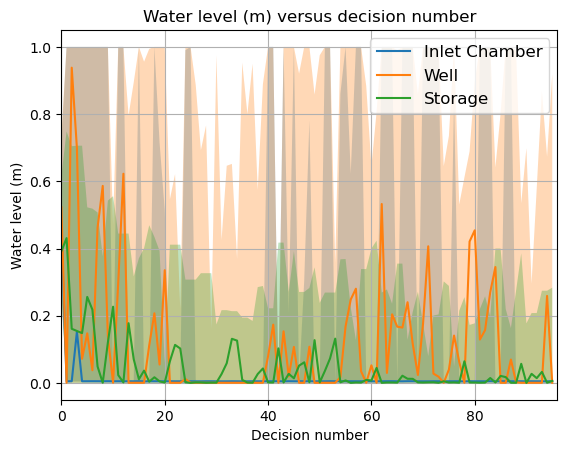

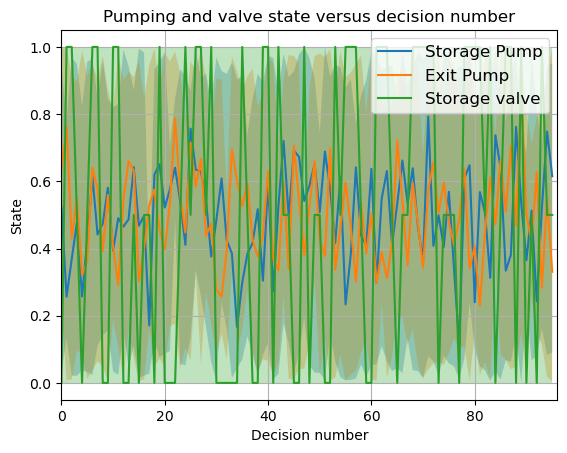

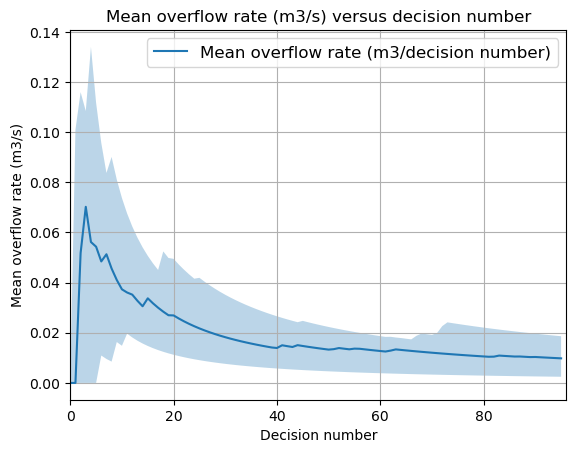

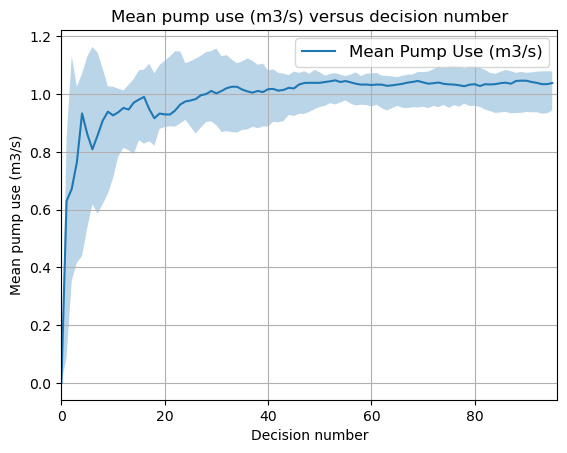

random complete!



testing greedy...


100%|██████████| 96/96 [00:07<00:00, 13.47it/s]


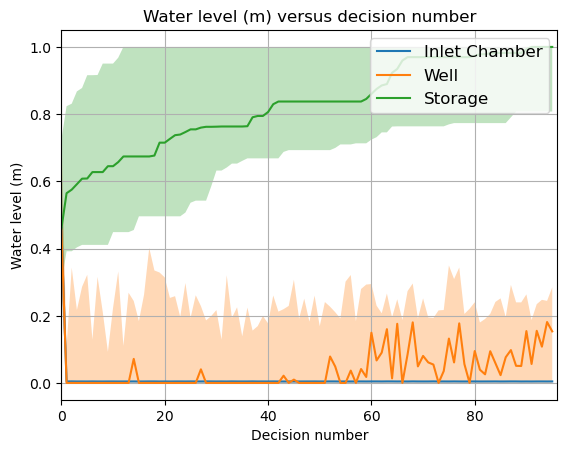

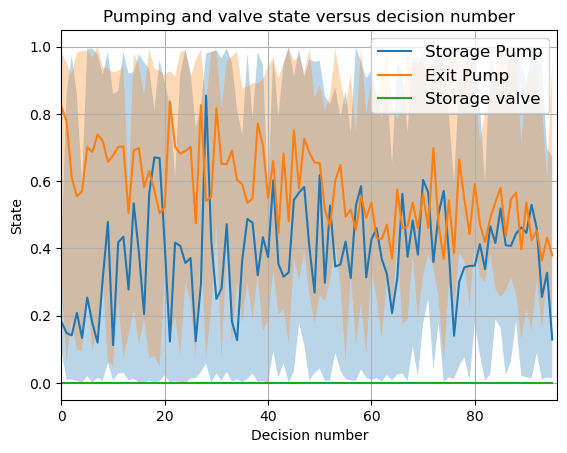

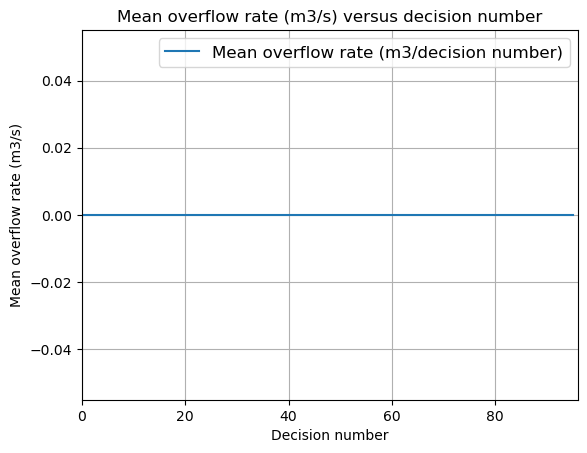

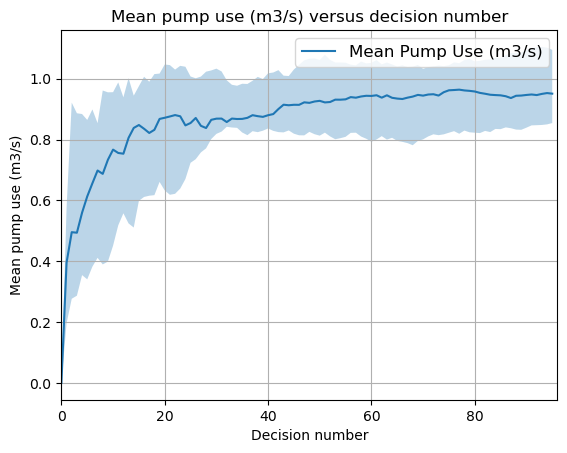

greedy complete!



testing plc...


100%|██████████| 96/96 [00:00<00:00, 98.80it/s] 


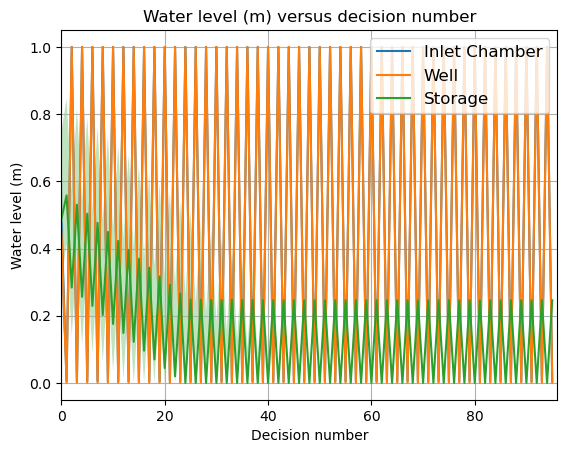

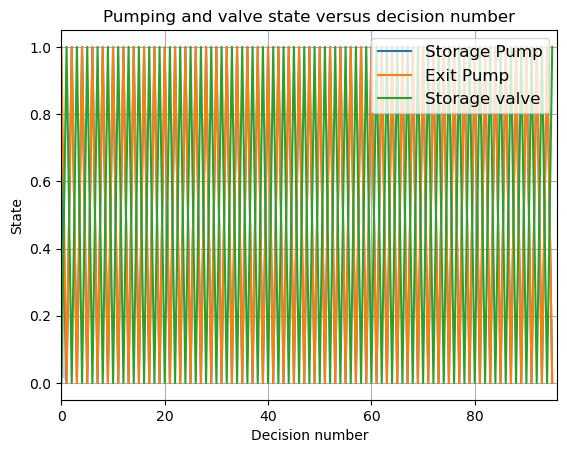

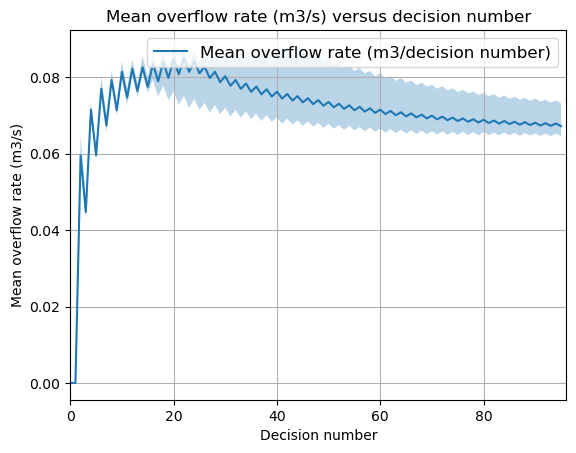

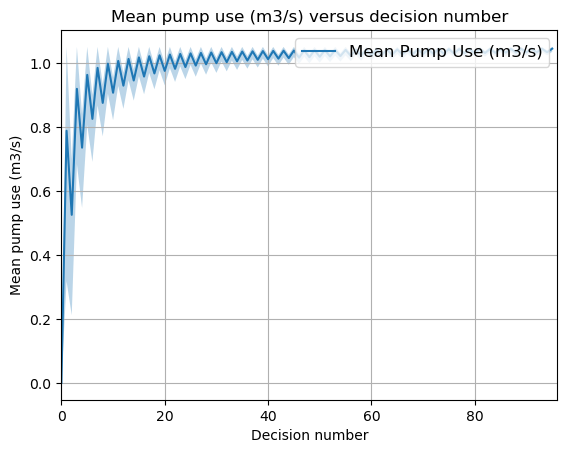

plc complete!



testing actorcritic...


100%|██████████| 96/96 [00:06<00:00, 14.74it/s]


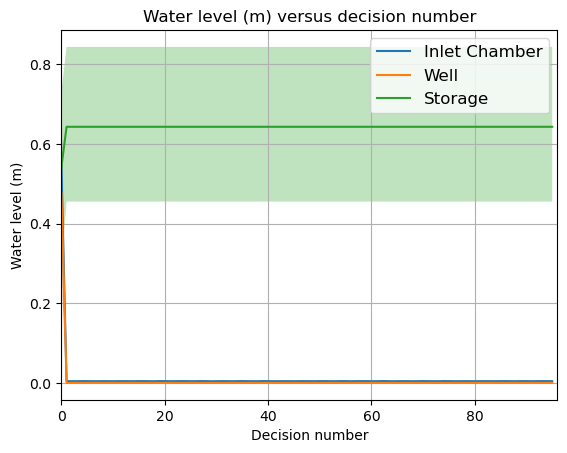

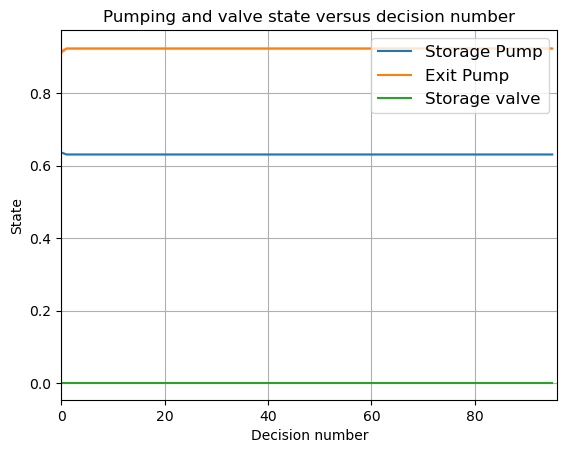

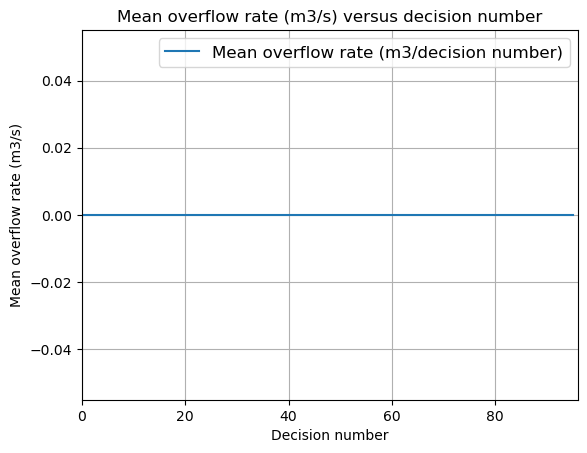

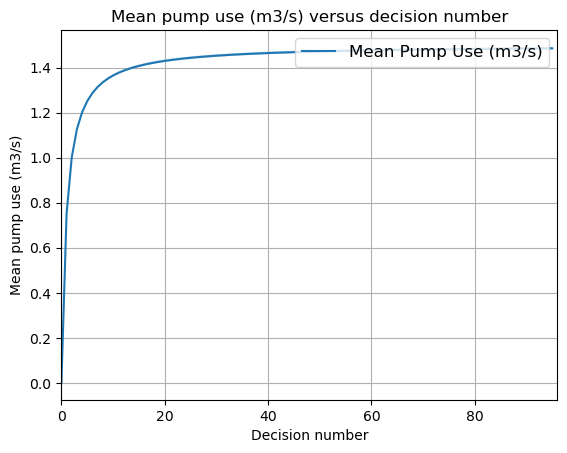

actorcritic complete!



testing imitationactorcritic...


100%|██████████| 96/96 [00:07<00:00, 13.61it/s]


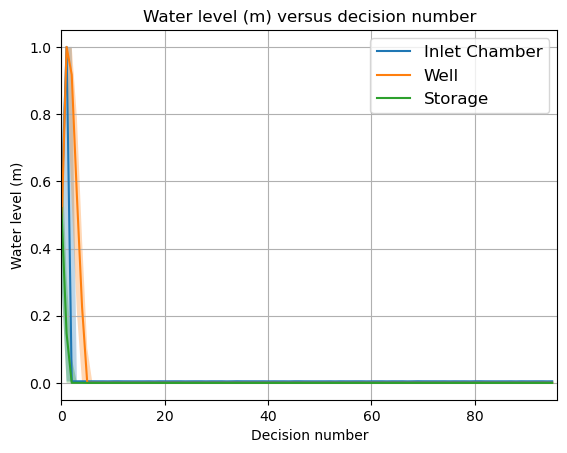

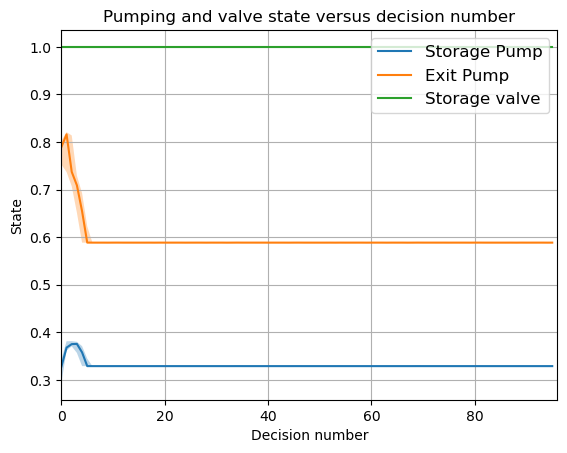

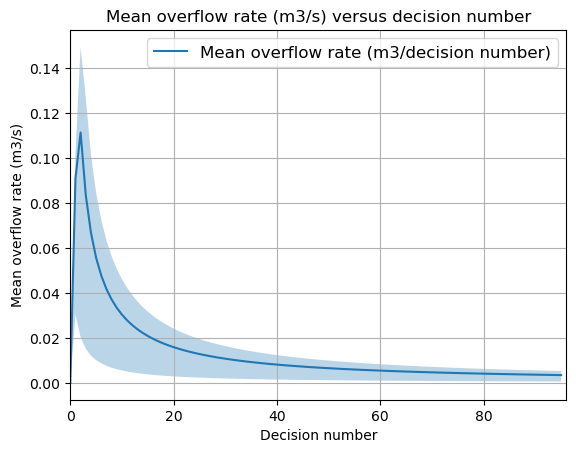

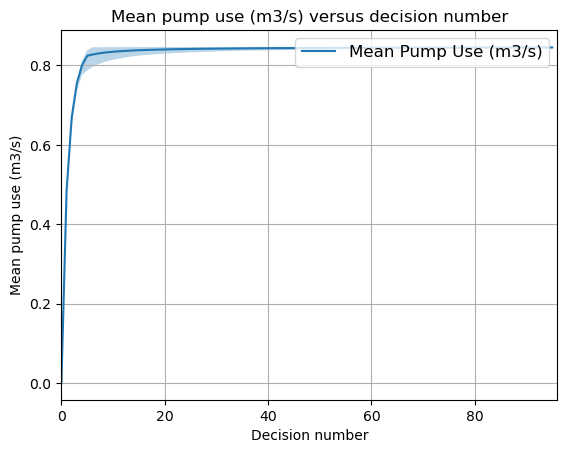

imitationactorcritic complete!



testing finetunedimitationactorcritic...


100%|██████████| 96/96 [00:07<00:00, 13.23it/s]


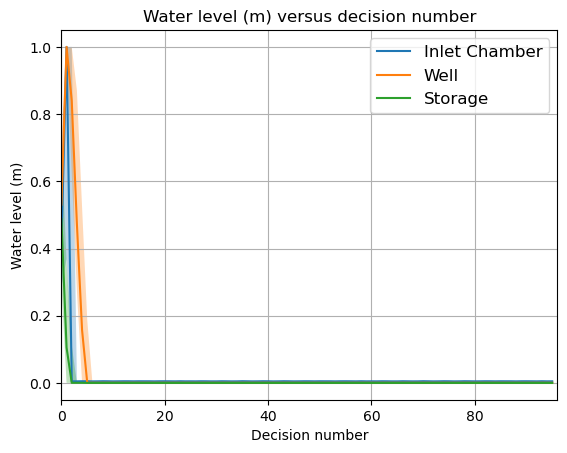

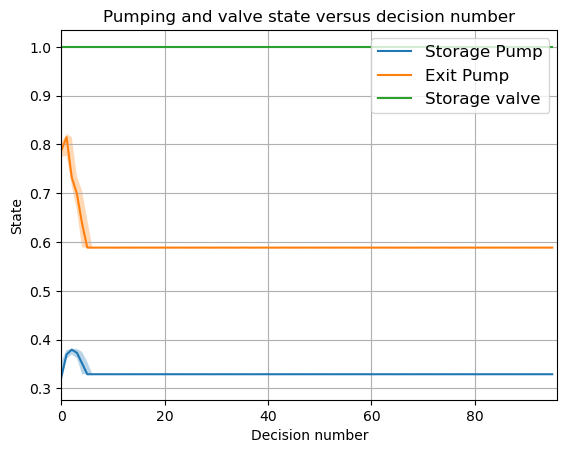

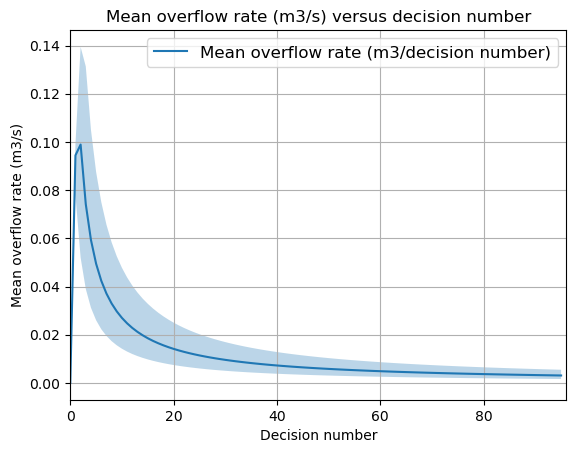

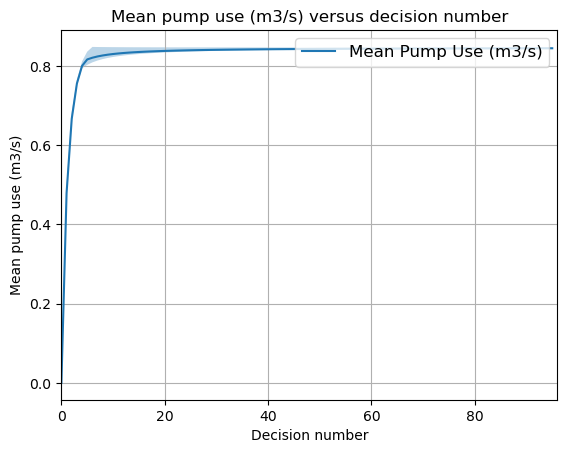

finetunedimitationactorcritic complete!



testing deepq...


100%|██████████| 96/96 [02:32<00:00,  1.59s/it]


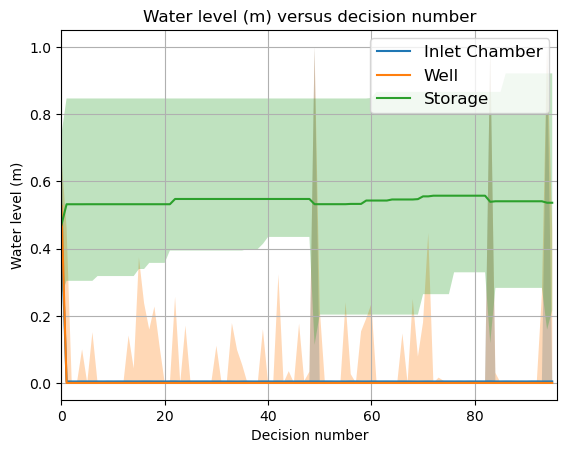

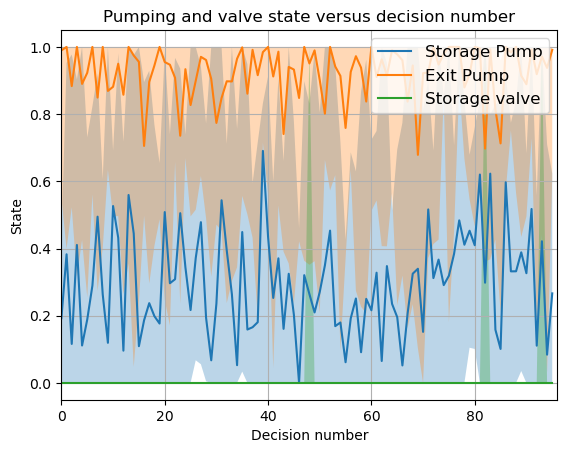

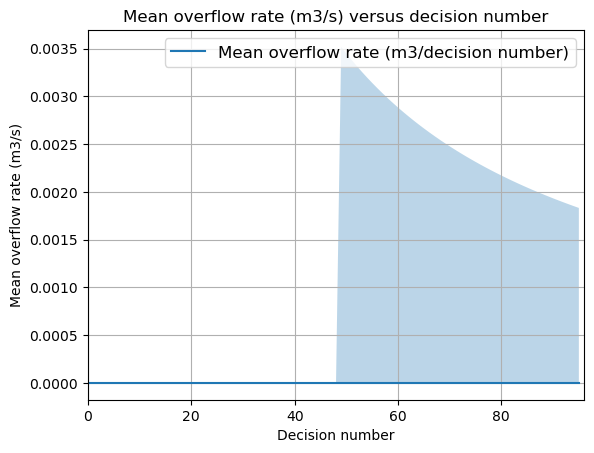

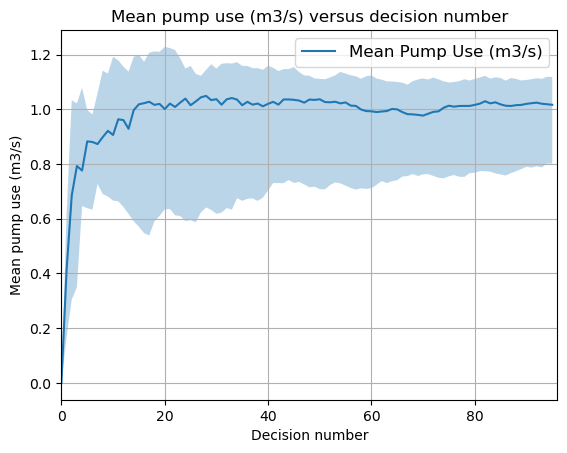

deepq complete!



testing imitationq...


100%|██████████| 96/96 [02:26<00:00,  1.53s/it]


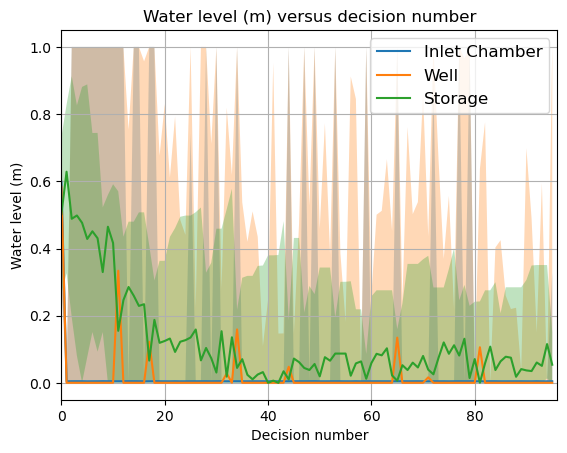

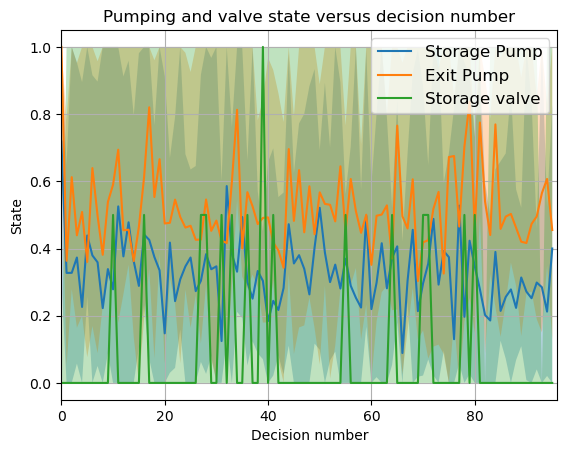

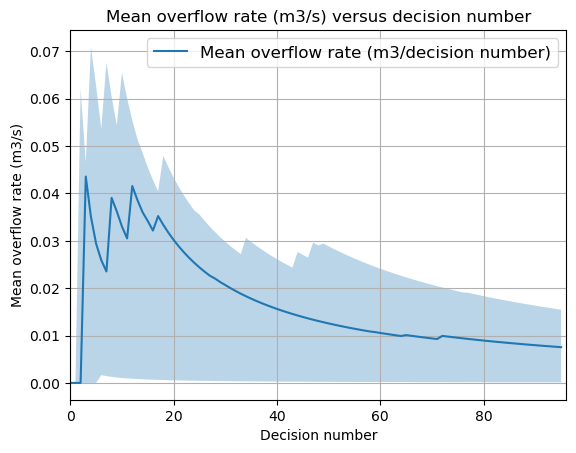

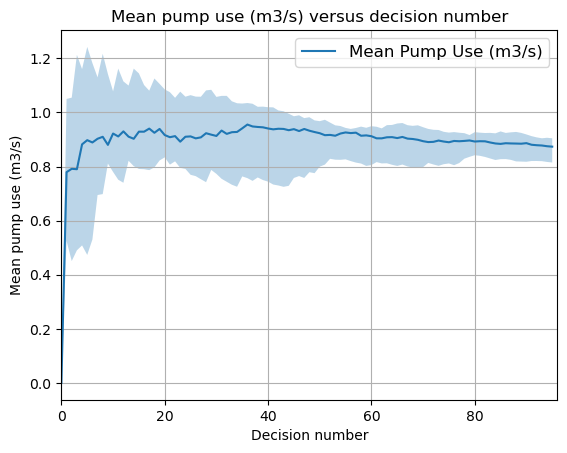

imitationq complete!



testing finetunedimitationq...


100%|██████████| 96/96 [02:12<00:00,  1.38s/it]


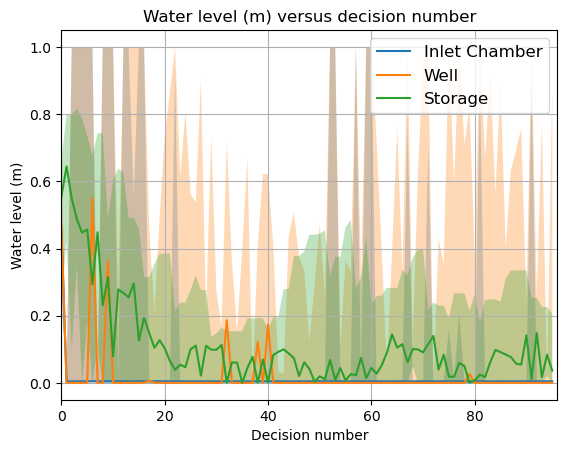

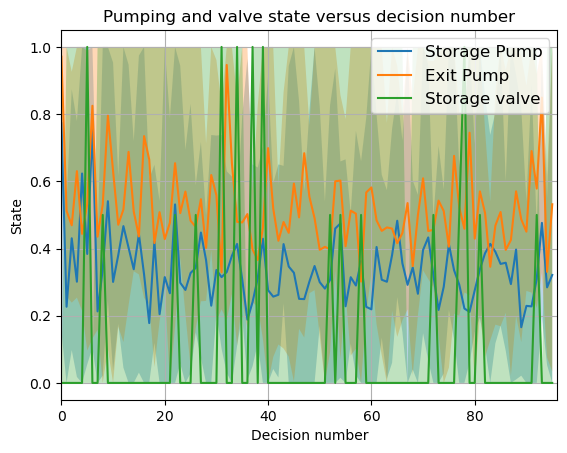

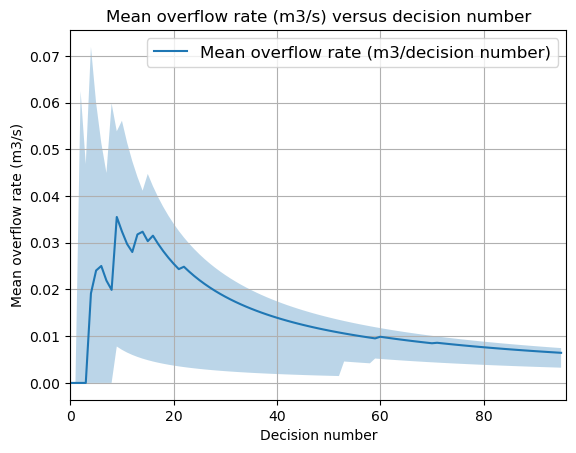

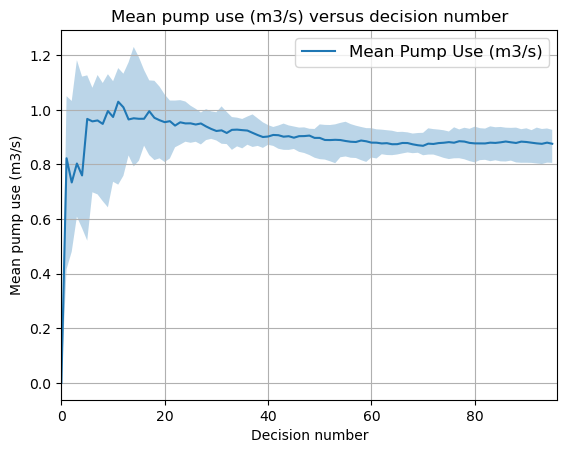

finetunedimitationq complete!





In [19]:
handler = AgentHandler(random)
handler.fullTest(savename = "random")

handler = AgentHandler(greedy)
handler.fullTest(savename = "greedy")

handler = AgentHandler(plc)
handler.fullTest(savename = "plc")

handler = AgentHandler(actorcritic)
handler.fullTest(savename = "actorcritic")

handler = AgentHandler(imitationactorcritic)
handler.fullTest(savename = "imitationactorcritic")

handler = AgentHandler(finetunedimitationactorcritic)
handler.fullTest(savename = "finetunedimitationactorcritic")

handler = AgentHandler(deepq)
handler.fullTest(savename = "deepq")

handler = AgentHandler(imitationq)
handler.fullTest(savename = "imitationq")

handler = AgentHandler(finetunedimitationq)
handler.fullTest(savename = "finetunedimitationq")
